# Hybrid Quantum Design: Transmon-Resonator Optimization

## Introduction

Hello. My name is minchae and I'm studying Electrical Engineering in NUS. In this project, I design and analyse the quantum chip made of a single Transmon qubit coupled to Meander Resonator using Qiskit Metal. I will start by designing the quantum chip. Then, I move onto analysing the relationship between pad height with anharmonicity and qubic frequency. <br> This was a day-worth of work. I started by installing Qiskit Metal, then ended up with the content of this Jupyter notebook. I used LLM tools like Gemini and Claude. Below is a list of videos and websites have been very helpful. I used Quantum_metal and Qiskit_metal_GUI to analyse the results. <br>

- Qiskit Community [https://qiskit-community.github.io/qiskit-metal/index.html]<br>
- Quantum Hardware Design: Energy, Circuits, and Metal | Qiskit Seminar Series with Zlatko Minev [https://www.youtube.com/watch?v=jjdYHZ0qxcY]<br>
- Videos from Zlatko Minev, Ph.D. [https://www.zlatko-minev.com/education]<br>
- Video from Quantum Computing, TCAD and Semiconductor Devices [https://www.youtube.com/watch?v=CjYHx48jCKg&list=PLnK6MrIqGXsKpkN3nL1OlxW6Gr6srYt0C&index=3]

## Background Context

The diagram below shows a super computer. The 'quantum' part of the quantum computer happens in the 'Resonator and Qubit' part at the bottom.


<div align="center">
  <img src="Superconducting Qubit System Overview.png" style="width:70%;">
</div>
Source: [https://www.youtube.com/watch?v=CjYHx48jCKg&list=PLnK6MrIqGXsKpkN3nL1OlxW6Gr6srYt0C&index=3]

What I did in this project is to design and analyse the Resonator and the Qubit. <br>

### Resonator
To model the resonator, I used a Simple Coplanar Waveguide (CPW) Meander resonator. It acts as a bridge that carries microwave signals from the room-temperature electronics down to the Resonator & Qubit at 10 mK. It looks like a squiggly line. It also plays a key role in reading the quantum state of the qubit without destroying the quantum information. 

<div align="center">
  <img src="Resonator.png" style="width:50%;">
</div>
Source: [https://qiskit-community.github.io/qiskit-metal/circuit-examples/B.Resonators/11-Resonator_Meander.html]

### Transmon Qubit
To model the qubit, I used single transmon. Transmon is a physical, superconducting circuit designed to act as a qubit. It acts as an oscillator. It is consisted of two big metal pads (that act like a capacitor), which is connected by a Josephson Junction (non-linear inductor). <br>

<div align="center">
  <img src="Magnetic flux and inductance of a transmon.png" style="width:70%;">
</div>
Source: [https://raw.githubusercontent.com/qiskit-community/intro-to-quantum-computing-and-quantum-hardware/refs/heads/master/lectures/introqcqh-lecture-notes-6.pdf]

### Pad height 
This refers to the length of the two large rectangular metal plates of Transmon Qubit. These plates act as a capacitor. When you increase the pad height, you increase the surface area, which increases the Capacitance (C).

### Anharmonicity
Anharmonicity is the degree of when the energy level becomes unevenly separated. It is important for qubic to be nonlinear. For example, if the energy gap between 0-->1 is same as 1-->2, then it is impossible to only talk to the 0 and 1 states without accidentally hitting the 2 state. <br> Anharmonicity is roughly proportional to the Charging Energy (E_C​), which is e^2/2C. As you increase the pad height (increasing C), the EC​ drops, making the qubit "less" anharmonic (closer to zero)

### Qubic frequency 
This is the energy difference between the ground state (∣0⟩) and the first excited state (∣1⟩) of the qubit, converted to GHz. Note that a transmon is essentially an LC circuit, as you increase the pad height (and thus capacitance), the "resonant" frequency of the qubit drops. Qubic frequency is equivalent to the resonant frequency of LC oscillator circuit, which is defined as f=1/(2*π*sqrt(LC))

## Code

Now let's dig into the code. <br>
By runnning this Jupyter notebook, I see the result in Qiskit_metal_GUI. <br>
To write the code, I referred to this documentation. <br>
https://qiskit-community.github.io/qiskit-metal/apidocs/designs.html

In [30]:
# Cell 1. Imports & setup 
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict

from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround

from qiskit_metal.analyses.quantization import LOManalysis

import scqubits as scq

Failed to read module file 'C:\Users\minch\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\minch\quantum-metal\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "C:\Users\minch\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9d in position 4651: character maps to <undefined>
Failed to read module file 'C:\Users\minch\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Tra

In [31]:
# Cell 2. Create design and GUI
design = designs.DesignPlanar()
design.overwrite_enabled = True

# Global CPW defaults
design.variables['cpw_width'] = '10um'
design.variables['cpw_gap']   = '6um'

gui = MetalGUI(design) #launches qiskit_metal GUI window. 

In cell 2, we are initialising the chip environment by setting the global microwave rules. 

In [32]:
# Cell 3. Add TransmonPocket Q1 at center
q1_options = dict(
    pos_x='0um',
    pos_y='0um',
    pad_height='90um',      # initial value; will be swept later
    connection_pads=dict(
        a=dict(             # readout / coupling pad
            loc_W='+1',
            loc_H='-1',
            pad_width='125um',
            pad_height='30um',
            cpw_extend='50um'
        )
    )
)

q1 = TransmonPocket(design, 'Q1', options=q1_options)

In cell 3, we are placing the transmon qubit at the centre of the GUI (Graphical User Interface).

In [33]:
# Cell 4. Add OpenToGround termination and readout resonator (RouteMeander)

# Termination for the resonator
readout_term = OpenToGround(
    design,
    'ReadoutTerm',
    options=dict(
        pos_x='2000um',  # place to the right of Q1
        pos_y='0um',
        orientation='0'
    )
)

# CPW options for the resonator
RouteMeander.get_template_options(design)
cpw_options = Dict(
    lead=Dict(
        start_straight='100um',
        end_straight='100um'
    ),
    trace_width='cpw_width',
    trace_gap='cpw_gap'
)

readout_opts = Dict(
    fillet='50um',
    pin_inputs=Dict(
        start_pin=Dict(component='Q1',         pin='a'),
        end_pin=Dict(  component='ReadoutTerm', pin='open') #soldering the resonator to the transmon. 
    ),
    total_length='8mm'
)
readout_opts.update(cpw_options)

readout = RouteMeander(design, 'Readout', readout_opts)

# Rebuild and show layout
gui.rebuild()
gui.autoscale()

In cell 4, we are adding the meander resonator (squiggly line). <br> 
After cell 4, we see this physical layout in Qiskit_metal_GUI. 

<div align="center">
  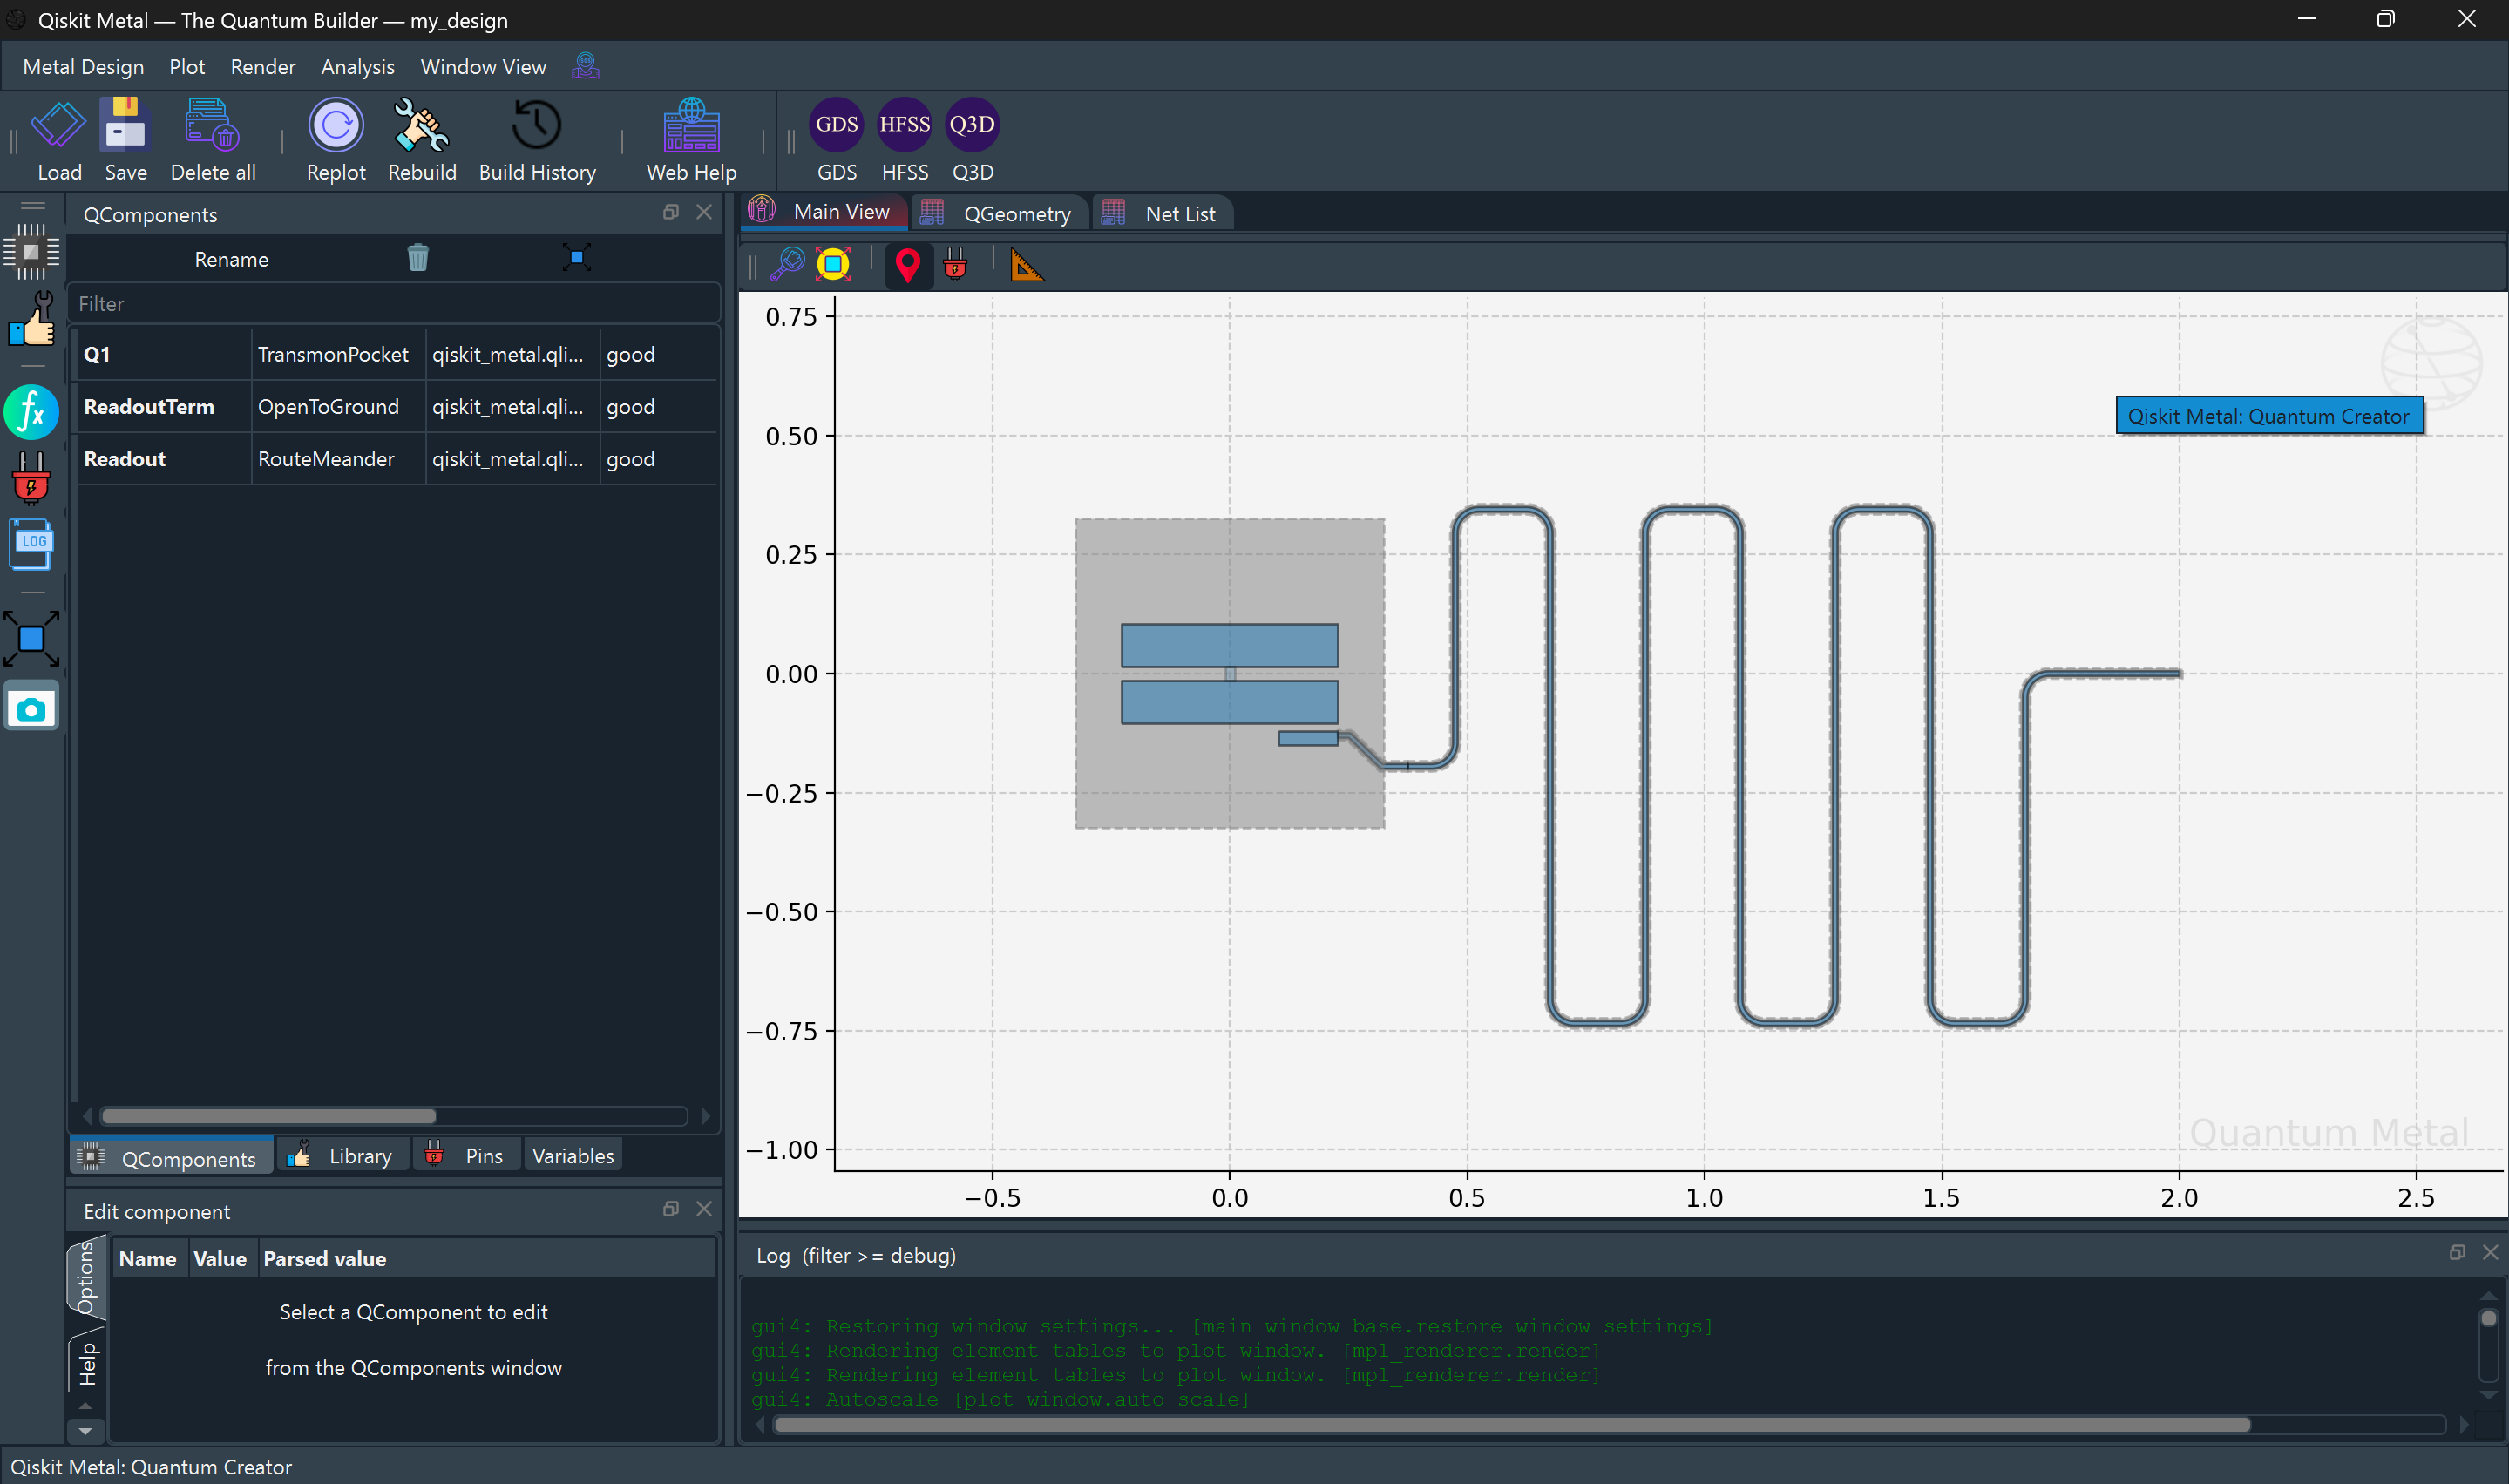
</div>

In [34]:
# Cell 5. Set up LOM analysis

lom = LOManalysis(design, "q3d")

# Junction & frequency assumptions for LOM (adjust to your device)
lom.setup.junctions = Dict({'Lj': 12.0, 'Cj': 2.0})  # Lj in nH, Cj in fF. This is of Transmon. 
lom.setup.freq_readout = 7.0                         # GHz
lom.setup.freq_bus = []                              # no bus lines here

In cell 5, we utilise Lumped Oscillator Model(LOM) to perform a parametric sweep of the qubit's geometry. Here, we define the inductance and the capacitance. <br>
LOM simplifies the quantum chip into R,L and C values that we know from classical electricity. <br>
Recall that C comes from the pads in transmon, and L comes from Josephson-Junction in transmon as well. 

In [35]:
# Cell 6. Improved Anharmonicity function (Bypassing Ansys)
def calculate_anharmonicity_no_ansys(pad_height_um: float) -> float:
    # 1. Physical Assumption: 
    # Total Capacitance (C_tot) = C_pads + C_junction
    # A standard TransmonPocket has ~1.2 fF of capacitance per 1 um of pad_height.
    # Plus a constant base capacitance of ~30 fF from the rest of the geometry.
    estimated_C_fF = (pad_height_um * 1.1) + 35.0 
    
    # 2. Convert Capacitance to Charging Energy (EC)
    # Formula: EC = e^2 / (2 * C_tot)
    # In GHz: EC_GHz approx 19.36 / C_fF
    EC_GHz = 19.36 / estimated_C_fF
    
    # 3. Define Josephson Energy (EJ)
    # We'll keep this constant, assuming a standard Junction size
    EJ_GHz = 15.0 

    # 4. Use scqubits to find energy levels
    transmon = scq.Transmon(
        EJ=EJ_GHz,
        EC=EC_GHz,
        ng=0.0,
        ncut=30
    )

    evals = transmon.eigenvals(evals_count=3)  # Result in GHz
    E0, E1, E2 = evals

    anharm = (E2 - E1) - (E1 - E0) # This will be a negative value
    return float(anharm)
    


In cell 6, we take the pad height and calculate anharmonicity, without using a microwave simulation software Ansys. <br>
Note that we are using scqubits library to solve the Transmon Hamiltonian. As a result, we calculate the first three energy levels of the qubit. <br>
To sum up, we are achieving this in this cell: Pad height --> Capacitance (C) --> Charging Energy (EC) --> Anharmonicity (alpha).

In [36]:
# Cell 7. Sweep and Plot 
pad_heights = np.linspace(60.0, 150.0, 10) 
anharm_vals_mhz = []
freq_vals_ghz = []

for ph in pad_heights:
    q1.options['pad_height'] = f'{ph}um'
    design.rebuild()
    
    # Use the function from Cell 1
    # Let's quickly modify the function to return both
    estimated_C_fF = (ph * 1.1) + 35.0 
    EC_GHz = 19.36 / estimated_C_fF
    EJ_GHz = 15.0 
    transmon = scq.Transmon(EJ=EJ_GHz, EC=EC_GHz, ng=0.0, ncut=30)
    evals = transmon.eigenvals(evals_count=2) 
    
    freq_vals_ghz.append(evals[1] - evals[0]) #energy gap btwn ground & first excited state.
    anharm_vals_mhz.append(calculate_anharmonicity_no_ansys(ph) * 1000.0)

# Plot 1: Anharmonicity
plt.figure(figsize=(6,4))
plt.plot(pad_heights, anharm_vals_mhz, 'o-')
plt.title('Pad Height vs Anharmonicity')
plt.ylabel('MHz')
plt.show()

# Plot 2: Frequency (The new one you need!)
plt.figure(figsize=(6,4))
plt.plot(pad_heights, freq_vals_ghz, 's-', color='orange')
plt.title('Pad Height vs Qubit Frequency')
plt.ylabel('GHz')
plt.show()
# At this point MetalGUI(design) is already running via `gui`,
# and you can interact with the layout window.

In cell 7, we plot two graphs that are shown below. 

<div align="center">
  <img src="Graphs comparison.png" style="width:90%;">
</div>

## Conclusion

<div align="center">
  <img src="Conclusion qiskit.png" style="width:70%;">
</div>

This project successfully demonstrated the design-to-physics workflow for a superconducting quantum device using Qiskit Metal. By performing a parametric sweep of the qubit’s geometry, we mapped how physical layout decisions directly dictate quantum performance metrics.<br>
The core finding of this study is that the transmon pad height acts as the primary mechanical lever for tuning the device's electrical properties. As the pad height increases, the surface area grows, directly increasing the Capacitance (C) of the circuit. <br>
- Qubit Frequency (f): Following the classical LC resonant frequency formula, the frequency is inversely proportional to the square root of capacitance. Our results confirmed this, showing a smooth downward trend from 4.6 GHz to 3.3 GHz as the pads were enlarged. <br>
- Anharmonicity (α): Defined as the difference between the first two energy transitions, anharmonicity is approximately equal to the negative Charging Energy (−EC). Since EC=e2/2C, increasing the pad height reduces the charging energy, causing the anharmonicity to shift from -215 MHz toward -105 MHz. <br>

## Potential Area of Developments

### Qubit Hilbert Space
In this project, I have only covered the stages of Physical Layout to the Quanntum Hamiltonian analysis. From here onwards, it is possible to identify the Qubit Hilbert space as a simplified mathematical representation. <br>

<div align="center">
  <img src="Quantum Device Design.png" style="width:50%;">
</div>

Source: [https://www.youtube.com/watch?v=jjdYHZ0qxcY]

### Photonics Application
This setup can be used in the Transmon to Phonon interface. 
For example, an electric field form the resonator can push and pull a piezoelectric material. This physical pushing creates a phonon (defined as a lattice of vibrations) inside a photonic crystal. This enables storing quantum information in mechanical vibrations or to convert it into light for fiber-optic transmission. 

<div align="center">
  <img src="Quantum Photonics Application.png" style="width:50%;">
</div>

Source: [https://www.nature.com/articles/s41586-018-0717-7]

# Thank you.
7th March, 2026 <br>
Minchae Kwak <br>
mkwak@u.nus.edu <br>